# **K-Means Clustering Assignment By Rasha**

# KMeans Clustering

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Dog Horse KMeans Challenge

In [28]:
# Import Data
df_dh = pd.read_csv("https://raw.githubusercontent.com/gumdropsteve/datasets/master/dog_or_horse.csv")
# We picked variables that we need
X = df_dh[['height', 'weight']]
df_dh.head()

,height,weight,target,type
0,27.0,71.0,0.0,dog
1,27.0,92.0,0.0,dog
2,32.0,47.0,0.0,dog
3,30.0,90.0,0.0,dog
4,28.0,91.0,0.0,dog


In [29]:
# Scale Data
sc = StandardScaler()
# Fit & transform data.
X_scaled = sc.fit_transform(X)

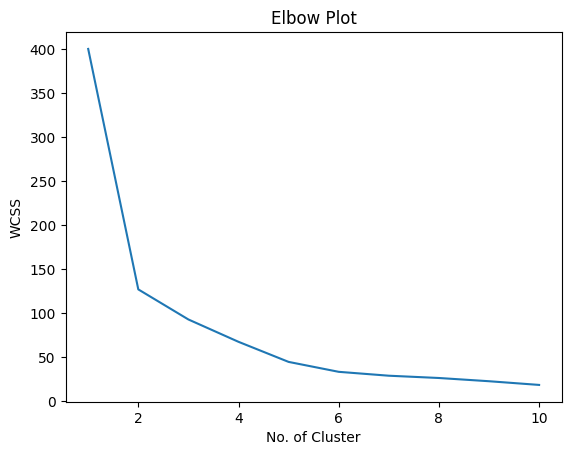

In [30]:
# Create Elbow Plot

# The elbow method depends on WCSS which stands for Within Cluster Sum of Squares

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Note: We are using K-mean++ to avoid the random initialization trap 
# Note: We are creating a plot of the WCSS for upto 10 clusters using the for loop
# The measurement we are using is the inertia 

plt.plot(range(1,11),wcss)
plt.title('Elbow Plot')
plt.xlabel('No. of Cluster')
plt.ylabel('WCSS')

plt.show()

In [31]:
# Apply KMeans and Plot KMeans Results and Actual Results
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

In [32]:
print(y_kmeans)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1]


In [33]:
# Cluster centeriods
print (kmeans.cluster_centers_)

[[-0.74395174 -0.70626086]
 [ 0.96628215  0.91732732]]


In [34]:
# assign the y_kmeans to a new column in the dataset
df_dh['kmean_prid']= y_kmeans
df_dh

,height,weight,target,type,kmean_prid
0,27.0,71.0,0.0,dog,0
1,27.0,92.0,0.0,dog,0
2,32.0,47.0,0.0,dog,0
3,30.0,90.0,0.0,dog,0
4,28.0,91.0,0.0,dog,0
...,...,...,...,...,...
195,55.0,140.0,1.0,horse,1
196,82.0,179.0,1.0,horse,1
197,46.0,132.0,1.0,horse,1
198,56.0,89.0,1.0,horse,0


### Plot the clusters including the centroid for each of the clusters as defined by K-Means

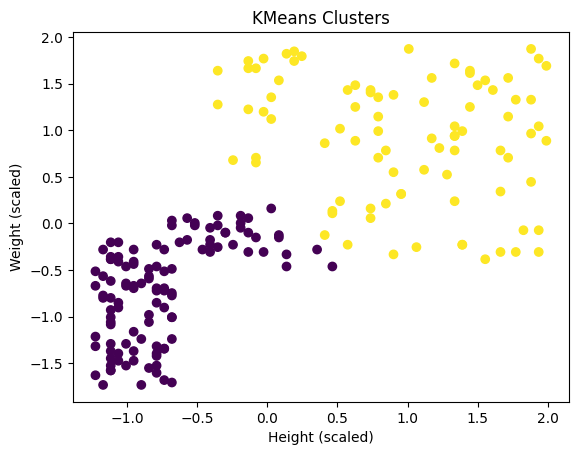

In [35]:
# Create a scatter plot of the actual results and the KMeans results
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis')
plt.title('KMeans Clusters')
plt.xlabel('Height (scaled)')
plt.ylabel('Weight (scaled)')
plt.show()

In [36]:
# replace dog with 1 and horse with 0 to help us caluclate the Accuracy Score
df_dh['target'] = df_dh['type'].map({'dog': 1, 'horse': 0})

In [37]:
# Calculate the number of correct predictions
(df_dh['type'] == df_dh['kmean_prid']).value_counts()

False    200
Name: count, dtype: int64

In [41]:
# Compute Accuracy Score of KMean Labels with True Labels
accuracy_score(df_dh['target'], df_dh['kmean_prid']) * 100

6.5

##### Seattle Weather KMeans Challenge

In [40]:
df_sea = pd.read_csv("https://raw.githubusercontent.com/gumdropsteve/datasets/master/seattle_weather_1948-2017.csv")
X_sea = df_sea[['tmax', 'tmin']]
df_sea.head()

,ds,prcp,tmax,tmin,rain
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [47]:
# Scale Data
scaler = StandardScaler()
# Fit & transform data.
X_sea_scaled = scaler.fit_transform(X_sea)

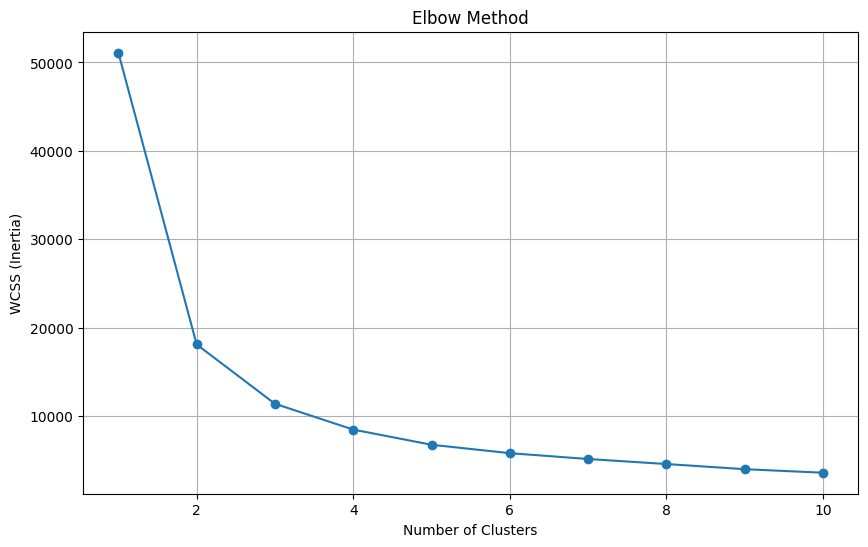

In [48]:
# Create Elbow Plot

# The elbow method depends on WCSS which stands for Within Cluster Sum of Squares
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_sea_scaled)
    wcss.append(kmeans.inertia_)



# Note: We are using K-mean++ to avoid the random initialization trap 
# Note: We are creating a plot of the WCSS for upto 10 clusters using the for loop
# The measurement we are using is the inertia 

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

# From the plot we can see that the optimal number of clusters in 4, but our target is 2 so we should pick 2.

[0 0 0 ... 0 0 0]


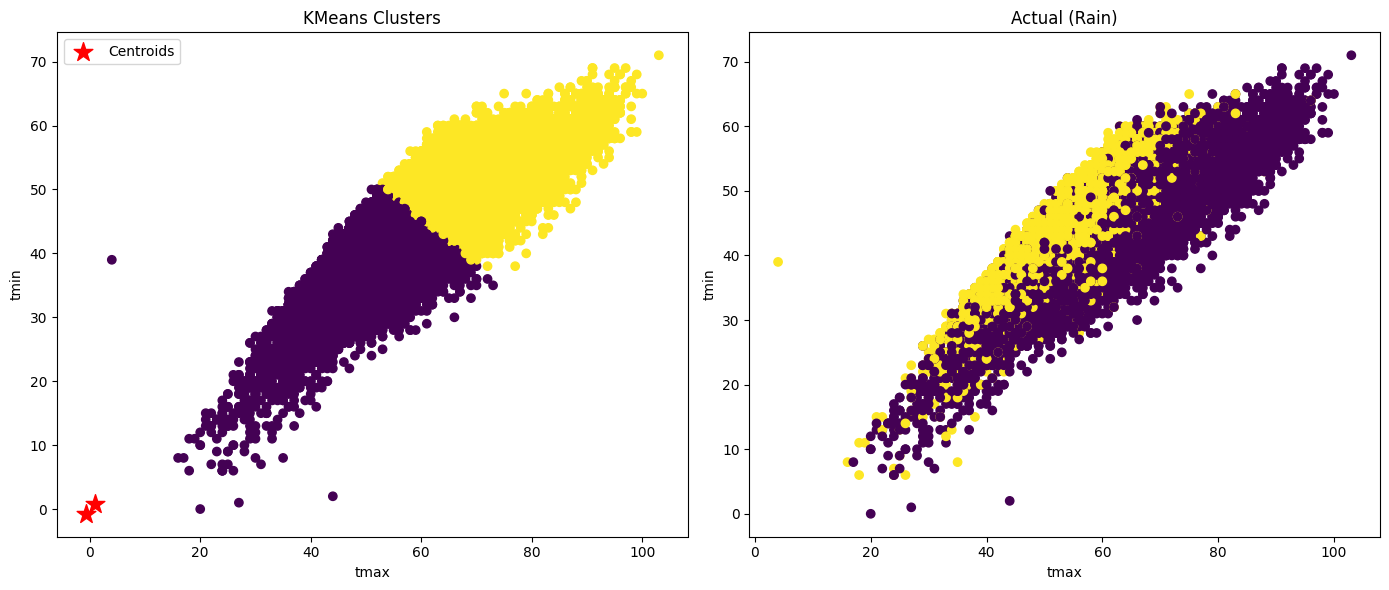

In [54]:
# Apply KMeans and Plot KMeans Results and Actual Results
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
y_sea_kmeans = kmeans.fit_predict(X_sea_scaled)

print(y_sea_kmeans)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# KMeans Results
axes[0].scatter(X_sea['tmax'], X_sea['tmin'], c=y_sea_kmeans, cmap='viridis')
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                s=200, c='red', marker='*', label='Centroids')
axes[0].set_title('KMeans Clusters')
axes[0].set_xlabel('tmax')
axes[0].set_ylabel('tmin')
axes[0].legend()

# Actual Results
axes[1].scatter(X_sea['tmax'], X_sea['tmin'], c=df_sea['rain'].map({True: 1, False: 0}), cmap='viridis')
axes[1].set_title('Actual (Rain)')
axes[1].set_xlabel('tmax')
axes[1].set_ylabel('tmin')

plt.tight_layout()
plt.show()

In [55]:
print(y_sea_kmeans)

[0 0 0 ... 0 0 0]


In [56]:
# assign the y_kmeans to a new column
df_sea['kmean_sea_prid']= y_sea_kmeans
df_sea

,ds,prcp,tmax,tmin,rain,kmean_sea_prid
0,1948-01-01,0.47,51,42,True,0
1,1948-01-02,0.59,45,36,True,0
2,1948-01-03,0.42,45,35,True,0
3,1948-01-04,0.31,45,34,True,0
4,1948-01-05,0.17,45,32,True,0
...,...,...,...,...,...,...
25546,2017-12-10,0.00,49,34,False,0
25547,2017-12-11,0.00,49,29,False,0
25548,2017-12-12,0.00,46,32,False,0
25549,2017-12-13,0.00,48,34,False,0


In [57]:
# replace True with 1 and False with 0 to help us caluclate the Accuracy Score
df_sea['rain'] = df_sea['rain'].map({True:1, False:0})

In [58]:
# Calculate the number of correct predictions
correct = (y_sea_kmeans == df_sea['rain'].map({True: 1, False: 0})).sum()
total = len(y_sea_kmeans)

In [59]:
df_sea.dropna(subset = ['rain'], inplace=True)

In [60]:
df_sea['rain'].isna().sum()

np.int64(0)

### Plot the clusters including the centroid for each of the clusters as defined by K-Means

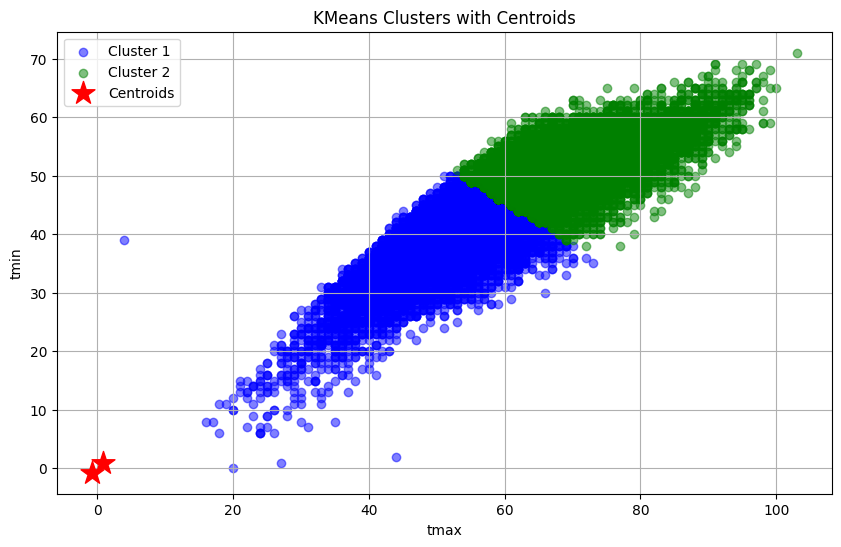

In [61]:
plt.figure(figsize=(10, 6))

plt.scatter(X_sea['tmax'][y_sea_kmeans == 0], X_sea['tmin'][y_sea_kmeans == 0], 
            c='blue', label='Cluster 1', alpha=0.5)
plt.scatter(X_sea['tmax'][y_sea_kmeans == 1], X_sea['tmin'][y_sea_kmeans == 1], 
            c='green', label='Cluster 2', alpha=0.5)

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='red', marker='*', label='Centroids', zorder=5)

plt.title('KMeans Clusters with Centroids')
plt.xlabel('tmax')
plt.ylabel('tmin')
plt.legend()
plt.grid(True)
plt.show()

In [62]:
# Compute Accuracy Score of KMean Labels with True Labels
accuracy_score(df_sea['rain'], df_sea['kmean_sea_prid'])*100

36.272898074213245

# Random Blob KMeans Challenge

- You dont have true labels for this data so this is truly an unsupervised dataset
- The blobs are randomly generated every time you run the cell and their characteristics are:
    - 2000-4000 data points
    - 10-30 blobs created

In [63]:
from sklearn.datasets import make_blobs
import numpy as np

n_blobs = np.random.randint(10, 31)
n_samples = np.random.randint(2000, 4001)

df_blob, _ = make_blobs(n_samples=n_samples, centers=n_blobs, random_state=None)

In [64]:
# Scale Data
sc_blb = StandardScaler()
# Fit & transform data.
X_blb_sc = sc.fit_transform(df_blob)

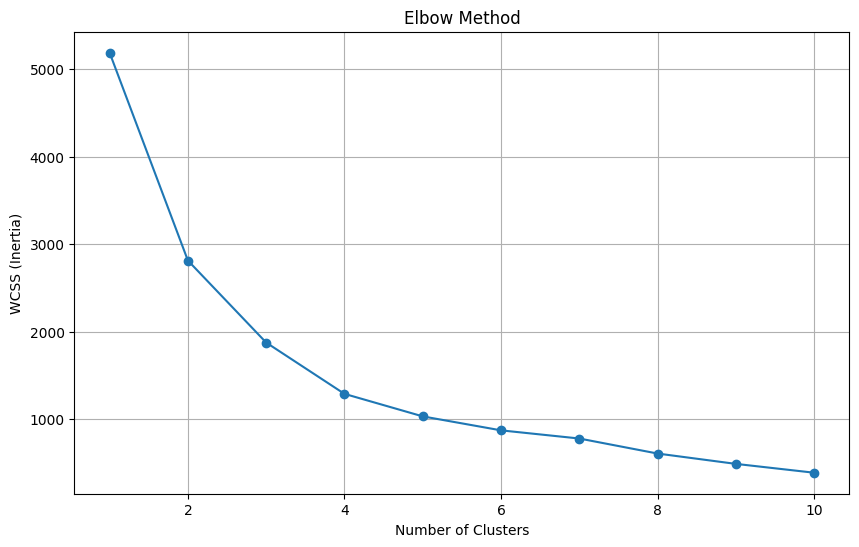

In [65]:
# Create Elbow Plot

# The elbow method depends on WCSS which stands for Within Cluster Sum of Squares

wcss = []
# Note: We are using K-mean++ to avoid the random initialization trap 
# Note: We are creating a plot of the WCSS for upto 10 clusters using the for loop
# The measurement we are using is the inertia 
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_blb_sc)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

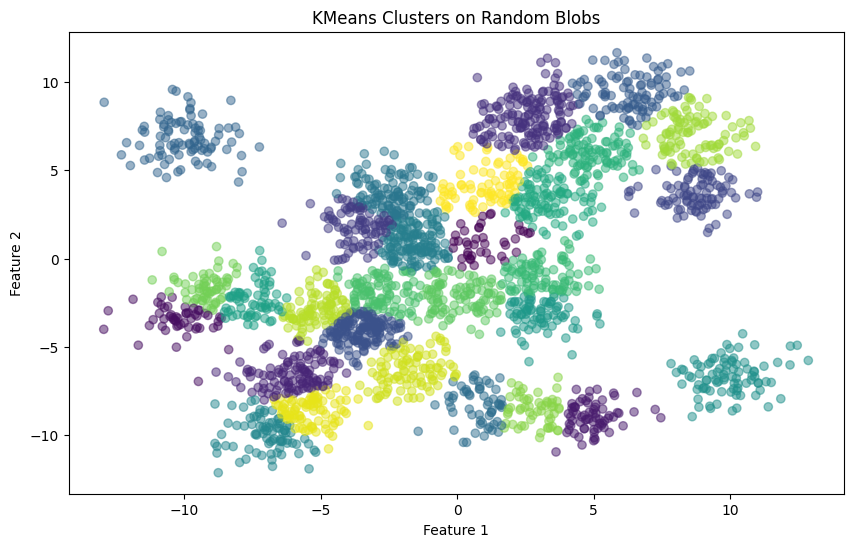

In [66]:
# Apply KMeans and Plot KMeans Results and Actual Results
kmeans_blb = KMeans(n_clusters=n_blobs, init='k-means++', random_state=42)
y_blb_kmeans = kmeans_blb.fit_predict(X_blb_sc)

plt.figure(figsize=(10, 6))
plt.scatter(df_blob[:, 0], df_blob[:, 1], c=y_blb_kmeans, cmap='viridis', alpha=0.5)
plt.title('KMeans Clusters on Random Blobs')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [67]:
print(y_blb_kmeans)

[11 19 17 ...  8  4  4]


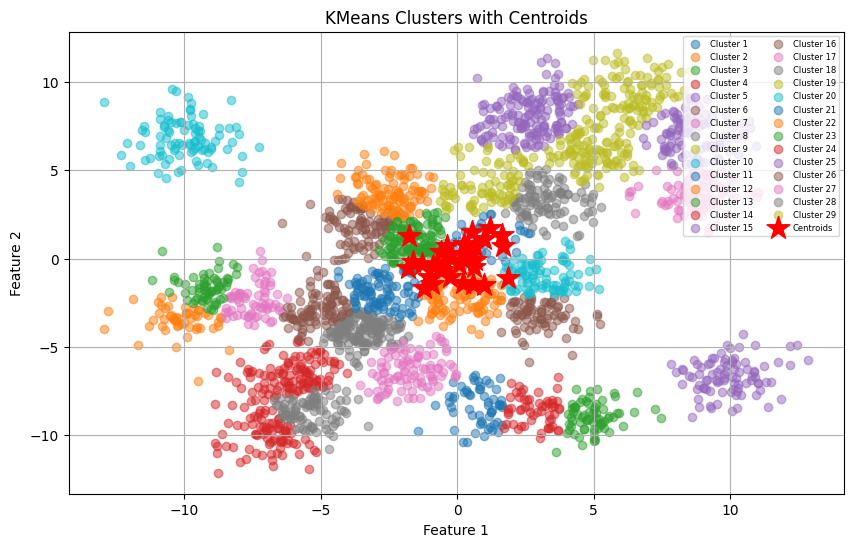

In [68]:
# Plot the clusters 
plt.figure(figsize=(10, 6))

for i in range(n_blobs):
    plt.scatter(df_blob[y_blb_kmeans == i, 0], df_blob[y_blb_kmeans == i, 1], alpha=0.5, label=f'Cluster {i+1}')

plt.scatter(kmeans_blb.cluster_centers_[:, 0], kmeans_blb.cluster_centers_[:, 1],
            s=300, c='red', marker='*', label='Centroids', zorder=5)

plt.title('KMeans Clusters with Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper right', fontsize=6, ncol=2)
plt.grid(True)
plt.show()